# Accessibility Analysis

## 🚑 How quick can you reach essential services?

- How do we prepare for a flood? <br>
    - Optimum evacuation routes before a flood: finding the nearest evacuation center
    - How long would it take to walk to the nearest evacuation center?
- Where will the flooding lead to disruptions?<br>
    - Who should be warned and evacuated?<br>
    - Which roads are affected?
    - Are the evacuation centers affected?




<div align="center">

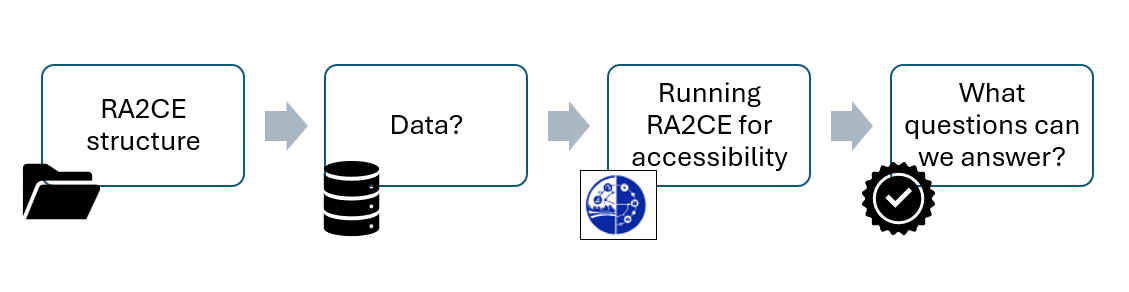

</div

<div class="alert alert-block alert-info"> 
<b>NOTE</b>: Accessibility analysis is built on the origin–destination (OD) framework. You provide one or more origins (start points) and destinations (end points), and RA2CE calculates the shortest or quickest route between them.
</div>

## Initialize and import RA2CE functions for the analysis

General imports

In [ ]:
#python imports
from pathlib import Path
import geopandas as gpd
import folium 
from shapely.geometry import Point,LineString, Polygon, box
import rasterio
import matplotlib.pyplot as plt
import osmnx 
import pandas as pd
from shapely.geometry import shape
import os
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
from folium.raster_layers import ImageOverlay

RA2CE-specific imports from the RA2CE python package

In [ ]:
#ra2ce imports
import ra2ce.network.networks_utils as nut
from ra2ce.network.network_config_data.enums.network_type_enum import NetworkTypeEnum
from ra2ce.network.network_config_data.enums.road_type_enum import RoadTypeEnum
from ra2ce.network.network_config_data.network_config_data import (NetworkConfigData,NetworkSection,HazardSection,OriginsDestinationsSection)
from ra2ce.network.network_config_data.enums.aggregate_wl_enum import AggregateWlEnum
from ra2ce.network.network_config_data.enums.source_enum import SourceEnum
from ra2ce.analysis.analysis_config_data.analysis_config_data import AnalysisSectionLosses, AnalysisConfigData
from ra2ce.analysis.analysis_config_data.enums.analysis_losses_enum import AnalysisLossesEnum
from ra2ce.analysis.analysis_config_data.enums.weighing_enum import WeighingEnum


from ra2ce.ra2ce_handler import Ra2ceHandler


## Make sure you have the RA2CE folder structure

<div align="center">

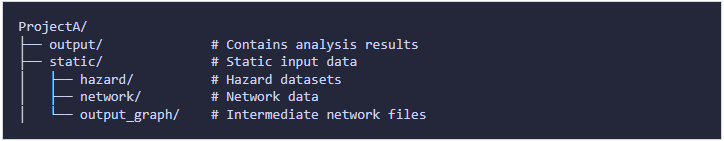

</div>

Set your working directories according to the RA2CE folder structure

In [ ]:
root_dir = Path('C:/RA2CE_Launch/data')
static_path=root_dir.joinpath("static")
network_path=static_path.joinpath("network")
hazard_path=static_path.joinpath("hazard")
output_path=static_path.joinpath("output_graph")
outputs = root_dir.joinpath("output")

print('Our working directory is :' + str(root_dir))

# Data preparation

<div align="center">

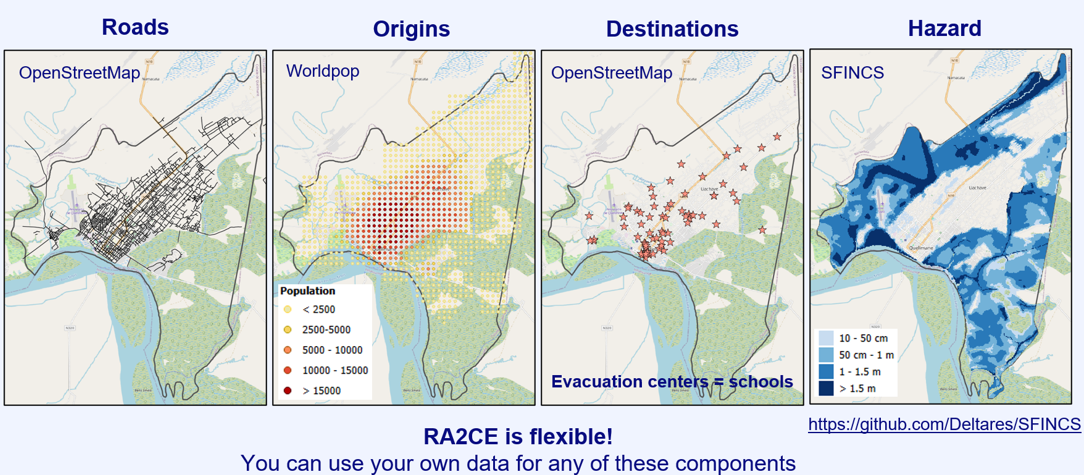

</div>

## 1. Study area: where are we in the world?

Using a geojson polygon

In [ ]:
from IPython.display import HTML

#Determine the extent:
AOI = network_path.joinpath("POLYGON.geojson")
AOI_gdf = gpd.read_file(AOI)
m = AOI_gdf.explore(width=700, height=500)

OD_polygon = shape(AOI_gdf.geometry.iloc[0])
#print(OD_polygon)

HTML(f"""
<div style="display:flex; justify-content:center; width:100%;">
  <div style="width:700px; height:500px; overflow:hidden;">
    {m._repr_html_()}
  </div>
</div>
""")

## 1. Road Network

Prepare the road network input data with RA2CE. Specifying the road types that will be included in the analysis. Downloading from OSM with RA2CE

In [ ]:
#Download Network and conduct hazard overlay

network_section = NetworkSection(
    source=SourceEnum.OSM_DOWNLOAD, #download the network from OSM 
    network_type=NetworkTypeEnum.DRIVE,
    polygon=AOI, #introduce the study area's polygon that you made based on the extent of the flood maps above. 
    road_types=[        #determine the level of detail you want to introduce to your road network. Mind that having more detail in a large area will slow down OSM download speed. 
        RoadTypeEnum.UNCLASSIFIED,
        RoadTypeEnum.RESIDENTIAL,
        RoadTypeEnum.TERTIARY,
        RoadTypeEnum.TERTIARY_LINK,
        RoadTypeEnum.SECONDARY,
        RoadTypeEnum.SECONDARY_LINK,
        RoadTypeEnum.PRIMARY,
        RoadTypeEnum.PRIMARY_LINK,
        RoadTypeEnum.TRUNK,
        RoadTypeEnum.MOTORWAY,
        RoadTypeEnum.MOTORWAY_LINK,
    ],
    attributes_to_exclude_in_simplification=['bridge', 'tunnel'],
    save_gpkg=True,
    reuse_network_output=True,
) 

network_config_data = NetworkConfigData(
    root_path=root_dir,
    static_path=root_dir / "static",
    network=network_section,
)

analysis_config_data = AnalysisConfigData(
    output_path=root_dir.joinpath("output"),
    static_path=root_dir.joinpath('static'),
)

handler = Ra2ceHandler.from_config(network=network_config_data, analysis=analysis_config_data)
handler.configure()

In [ ]:
# Load road network
road_network = output_path.joinpath("base_network.gpkg")
roads_gdf = gpd.read_file(road_network)


roads_gdf.explore(
    color="black",
    tiles="CartoDB Positron",
    legend=False
)

## 2. Preparing Origins and Destinations data

<div class="alert alert-block alert-info"> 
<b>NOTE</b>: To use RA2CE, you need to first prepare origin and destination shapefiles as input files
</div>



<div class="alert alert-danger">
    <b>NOTE</b>: In RA2CE, Origin and Destination files should be point files
</div>

<div align="center">

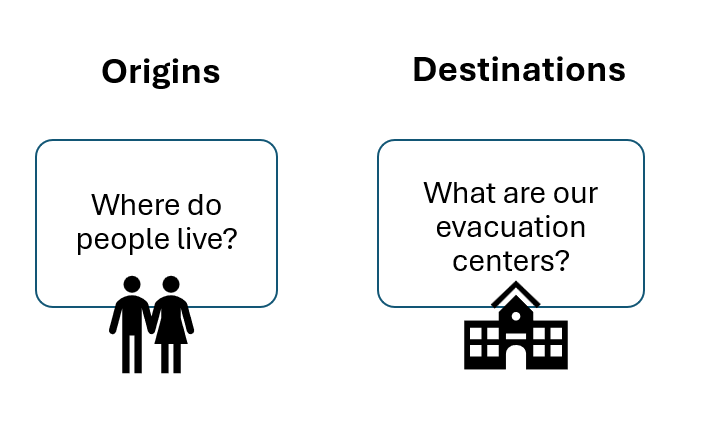

</div>

### Origins : Where do people live?

<div align="center">

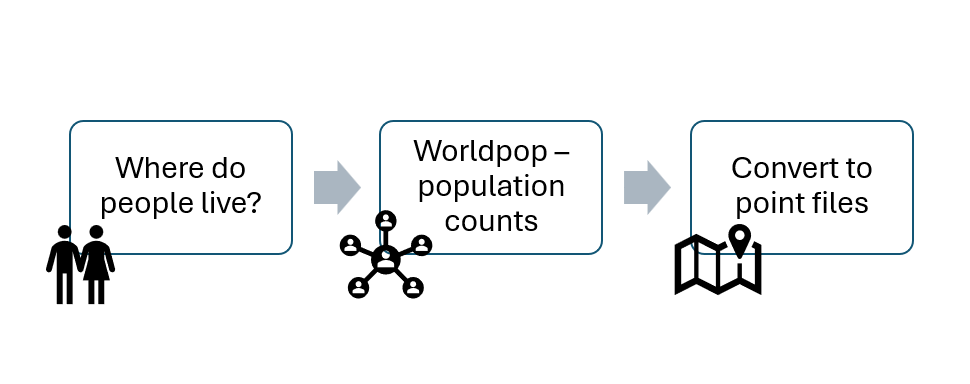

</div>

#### Downloading population raster from worldpop

In [ ]:
#!pip install worldpoppy
from worldpoppy import wp_raster

pop = wp_raster(
    product_name="pop_g2_alt",  # from your manifest: 2024 only
    aoi=AOI_gdf,
    years=2024                  # required because product is single-year
)

# Save AOI-clipped GeoTIFF
pop.rio.to_raster(network_path.joinpath("worldpop_2024_constrained_AOI.tif"))

#### Converting population raster to points

In [ ]:
target_resolution = 200   # meters

raster_path = network_path.joinpath("worldpop_2024_constrained_AOI.tif")
utm_raster_path = network_path.joinpath("worldpop_2024_UTM.tif")
resampled_path = network_path.joinpath("worldpop_2024_200m.tif")
output_points = network_path.joinpath("origins_200m_centroids.shp")

#  Load original raster (EPSG:4326)

with rasterio.open(raster_path) as src:
    src_data = src.read(1)
    src_crs = src.crs
    src_transform = src.transform
#  Determine UTM zone automatically
gdf_tmp = gpd.GeoDataFrame(geometry=[Point(src.bounds.left, src.bounds.bottom)], crs=src_crs)
utm_crs = gdf_tmp.estimate_utm_crs()

#  Reproject raster from EPSG:4326 → UTM (meters)
with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, utm_crs, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': utm_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(utm_raster_path, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=utm_crs,
            resampling=Resampling.bilinear
        )

#  Resample UTM raster to 200 m resolution
with rasterio.open(utm_raster_path) as src:
    # New transform with 200 m resolution
    transform_200 = rasterio.transform.from_origin(
        src.bounds.left, src.bounds.top, 
        target_resolution, 
        target_resolution
    )

    width_200 = int((src.bounds.right - src.bounds.left) / target_resolution)
    height_200 = int((src.bounds.top - src.bounds.bottom) / target_resolution)

    kwargs_200 = src.meta.copy()
    kwargs_200.update({
        'transform': transform_200,
        'width': width_200,
        'height': height_200
    })

    with rasterio.open(resampled_path, 'w', **kwargs_200) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform_200,
            dst_crs=utm_crs,
            resampling=Resampling.average    # Good for population data
        )

#  Extract centroids from the 200 m raster
with rasterio.open(resampled_path) as src:
    data = src.read(1)
    transform = src.transform
    crs = src.crs

    rows, cols = np.where(~np.isnan(data))  # or data > 0 if needed
    xs, ys = rasterio.transform.xy(transform, rows, cols, offset='center')

# Build GeoDataFrame in UTM
gdf = gpd.GeoDataFrame(
    {"value": data[rows, cols]},
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=crs
)

# Reproject back to EPSG:4326
gdf = gdf.to_crs("EPSG:4326")

# Save centroids
gdf.to_file(output_points)
print("Saved:", output_points)

origins = network_path.joinpath("origins_200m_centroids.shp")

#Clean the centroids
gdf_population = gpd.read_file(origins)
gdf_population = gdf_population[pd.notna(gdf_population['value']) & (gdf_population['value'] > 0)]
gdf_population.to_file(network_path.joinpath("origins_200m_clean.shp"), driver='ESRI Shapefile')

### B. Destinations: where are the evacuation centers? 
The evacuation centers in Quelimane are schools

<div class="alert alert-warning">
    <b>NOTE</b>: In this scenario we take schools as evacuation centers. You can define what you need to use as evacuation centers
</div>

<div align="center">

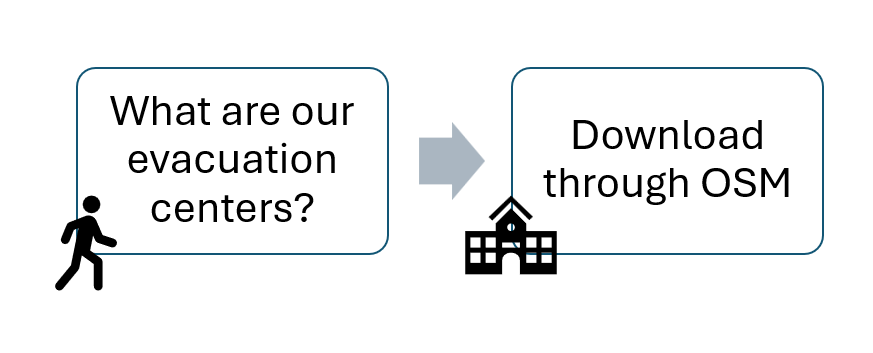

</div>

Download school data from OSM

In [ ]:
tags_basic_needs = {
    'amenity': [
        'school','kindergarten','college','university',
        'prep_school','music_school','language_school','faculty','training'
    ],
    'building': ['school']
}

features = osmnx.features_from_polygon(polygon=OD_polygon, tags=tags_basic_needs)
features['ID'] = range(len(features))
Destinations = features[["ID","amenity","name","geometry"]]
Destinations.rename(columns={"amenity": "category"}, inplace=True)
Destinations["geometry"] = Destinations.geometry.apply(lambda geom: geom.representative_point())

Destinations.to_file(network_path.joinpath("Destinations.shp"), driver='ESRI Shapefile')

In [ ]:

#population data
origins = network_path.joinpath("origins_200m_clean.shp")

gdf_population = gpd.read_file(origins)
#gdf_population['geometry'] = gdf_population.geometry.buffer(0.00090, cap_style=3)

#healthcare facilities data
destinations = network_path.joinpath("Destinations.shp")
gdf_healthcare = gpd.read_file(destinations)

centroid = gdf_healthcare.geometry.unary_union.centroid
latitude = centroid.y
longitude = centroid.x
m = folium.Map(location=[latitude, longitude], zoom_start=13, tiles='CartoDB Positron')

gdf_population.explore(m=m, column='value', cmap='Spectral_r', legend=True, tiles=None)

for idx, row in gdf_healthcare.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        #tooltip=row['Name'],
        zoom_start=12,
        icon=folium.Icon(color='black', icon='fa-hospital', prefix='fa')
    ).add_to(m)
m

## 3. Load the hazard Map

In [ ]:
import rasterio
import rasterio.mask
import matplotlib.pyplot as plt
import numpy as np

print([Path(file) for file in hazard_path.glob("*.tif")])

tif_path = list(hazard_path.glob("*.tif"))[0]

with rasterio.open(tif_path) as src:
    # AOI geometry must be in same CRS
    AOI = AOI_gdf.to_crs(src.crs)

    out_image, out_transform = rasterio.mask.mask(
        src,
        AOI.geometry,
        crop=True,
        nodata=src.nodata
    )
    data = out_image[0]

if src.nodata is not None:
    data = np.where(data == src.nodata, np.nan, data)

plt.figure(figsize=(9, 8))
plt.imshow(data, cmap="Blues", origin="upper")
plt.colorbar(label="Flood depth (m)")
plt.title("Hazard Map")
plt.axis("off")
plt.show()

### Summary : Lets visualize the input data we have so far

In [ ]:
import folium
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
from matplotlib.colors import ListedColormap

origins = network_path.joinpath("origins_200m_clean.shp")
roads = output_path.joinpath("base_network.gpkg")

gdf_population = gpd.read_file(origins)

# Healthcare facilities
destinations = network_path.joinpath("Destinations.shp")
gdf_healthcare = gpd.read_file(destinations)

# AOI
   # <-- ensure AOI_path is defined

AOI = network_path.joinpath("POLYGON.geojson")
AOI_gdf = gpd.read_file(AOI)


centroid = gdf_healthcare.geometry.unary_union.centroid
m = folium.Map(
    location=[centroid.y, centroid.x],
    zoom_start=13,
    tiles='CartoDB Positron'
)

gdf_population.explore(
    m=m,
    column='value',
    cmap='turbo',
    name="Population",
    legend=True,
    tiles=None
)


hc_group = folium.FeatureGroup(name="Evacuation Centers", show=True)

for _, row in gdf_healthcare.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='black', icon='fa-hospital', prefix='fa')
    ).add_to(hc_group)

hc_group.add_to(m)

gdf_roads = gpd.read_file(roads)
gdf_roads = gdf_roads[gdf_roads.geometry.notna()]

folium.GeoJson(
    gdf_roads,
    name="Road network",
    style_function=lambda feature: {
        'color': 'black',
        'weight': 2,
        'opacity': 0.8
    }
).add_to(m)


with rasterio.open(tif_path) as src:
    img = src.read(1)
    flood_crs = src.crs

    # Reproject AOI to raster CRS
    AOI = AOI_gdf.to_crs(flood_crs)

    # Clip raster to AOI
    out_img, out_transform = rasterio.mask.mask(
        src,
        AOI.geometry,
        crop=True,
        filled=True,
        nodata=np.nan
    )
    out_img = out_img[0]

    # Compute bounds of clipped raster
    out_bounds = rasterio.transform.array_bounds(
        out_img.shape[0], out_img.shape[1], out_transform
    )
    image_bounds = [
        [out_bounds[1], out_bounds[0]],
        [out_bounds[3], out_bounds[2]],
    ]



classified = np.full(out_img.shape, np.nan)

classified[(out_img >= 0.11) & (out_img < 0.45)] = 1
classified[(out_img >= 0.45) & (out_img < 1.0)]  = 2
classified[(out_img >= 1.0)  & (out_img < 1.7)]  = 3
classified[(out_img >= 1.7)]                     = 4

masked = np.ma.masked_invalid(classified)

# BLUE COLOR SCHEME (light → dark)
colors = [
    "#deebf7",  # light blue
    "#9ecae1",  # medium-light
    "#3182bd",  # medium-dark
    "#08519c"   # dark blue
]

cmap = ListedColormap(colors)
cmap.set_bad(alpha=0)

indices = masked.filled(np.nan) - 1
rgba = cmap(indices)
rgba = (rgba * 255).astype(np.uint8)

# Add flood raster layer
flood_layer = folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=image_bounds,
    name="Flood hazard",
    opacity=1.0,
    interactive=True,
    zindex=4
)
flood_layer.add_to(m)


aoi_layer = folium.FeatureGroup(name="AOI boundary")
AOI_clean = AOI_gdf.drop(
    columns=[col for col in AOI_gdf.columns if 'datetime' in str(AOI_gdf[col].dtype).lower()]
)

folium.GeoJson(
    AOI_clean,
    style_function=lambda feature: {
        'fillOpacity': 0,
        'color': 'black',
        'weight': 3
    }
).add_to(aoi_layer)

aoi_layer.add_to(m)



legend_html = '''
<div style="
    position: fixed;
    bottom: 20px; 
    left: 20px; 
    z-index:9999; 
    background-color: white;
    padding: 10px; 
    border: 2px solid black;
    font-size: 14px;
    line-height: 1.4;
">
<b>water depth</b><br>

<div>
    <span style="display:inline-block; width:20px; height:12px; background:#deebf7; border:1px solid black;"></span>
    ankle – knee &nbsp;&nbsp; 0.11 – 0.45 m
</div>

<div>
    <span style="display:inline-block; width:20px; height:12px; background:#9ecae1; border:1px solid black;"></span>
    knee – waist &nbsp;&nbsp; 0.45 – 1.0 m
</div>

<div>
    <span style="display:inline-block; width:20px; height:12px; background:#3182bd; border:1px solid black;"></span>
    waist – head &nbsp;&nbsp; 1.0 – 1.7 m
</div>

<div>
    <span style="display:inline-block; width:20px; height:12px; background:#08519c; border:1px solid black;"></span>
    above head &nbsp;&nbsp; > 1.7 m
</div>

</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))


folium.LayerControl().add_to(m)

m

#### Lets look at where our inputs are in the folder setup

## Running RA2CE: Origin-Destination Analysis (accessibility to nearest evacuation center)

Configure the RA2CE parameters for OD-analysis

In [ ]:
# defining the configuration parameters for the analysis

#Here we specify the origins and destinations we created earlier
origin_destination_section = OriginsDestinationsSection(
    origins=network_path.joinpath("origins_200m_clean.shp"), #put the name of origins data file
    destinations=network_path.joinpath("Destinations.shp"), #put the name of destinations data file
    origin_count="POPULATION",
)

#Here we specify the hazard map we defined earlier
hazard_section = HazardSection(
    hazard_map=[Path(file) for file in hazard_path.glob("*.tif")],    #[Path(geotiff_files[0])],
    hazard_field_name= ['waterdepth'],
    aggregate_wl = AggregateWlEnum.MAX, #we take the maximum water depth on road segments that intersect with the flood map
    hazard_crs = "EPSG:4326"
)

network_config_data = NetworkConfigData(
    root_path=root_dir,
    static_path=root_dir.joinpath('static'),
    network=network_section,
    hazard=hazard_section,
    origins_destinations=origin_destination_section,
)

analyse_section = AnalysisSectionLosses(
    name="OD_accessibility_analysis",
    analysis=AnalysisLossesEnum.MULTI_LINK_ORIGIN_CLOSEST_DESTINATION,
    weighing=WeighingEnum.LENGTH,
    calculate_route_without_disruption=True,
    save_csv=True,
    save_gpkg=True,
)

analysis_config_data = AnalysisConfigData(
    output_path=root_dir.joinpath("output"),
    static_path=root_dir.joinpath('static'),
    analyses=[analyse_section],
)

Run RA2CE based on above parameters

In [ ]:
handler = Ra2ceHandler.from_config(
    network=network_config_data,
    analysis=analysis_config_data
)
handler.configure()
handler.run_analysis()

In [ ]:
# First where are our results?

result_folder = outputs.joinpath("multi_link_origin_closest_destination")
optimal_routes_gdf_before = gpd.read_file(result_folder.joinpath('OD_accessibility_analysis_optimal_routes_without_hazard.gpkg'))
optimal_routes_gdf = gpd.read_file(result_folder.joinpath('OD_accessibility_analysis_optimal_routes_with_hazard.gpkg'))

origins = result_folder.joinpath("OD_accessibility_analysis_origins.gpkg")
destinations = result_folder.joinpath("OD_accessibility_analysis_destinations.gpkg")
origins_gdf = gpd.read_file(origins)
destinations_gdf = gpd.read_file(destinations)

print("Results are in: " + str(result_folder))

# Lets answer our questions

## 🚑 How quick can you reach essential services?

- What are the evacuation routes to shelters?<br>
- How long does it take to walk to an evacuation center?
- How do we prepare for a flood? <br>
    - Where will the flooding lead to disruptions?<br>
        - Which roads get flooded? <br>
        - Who should be warned and evacuated?<br>
        - Are the evacuation centers affected?


## What are the evacuation routes to shelters? (planning phase)

For every origin finding the closest shelter

In [ ]:


selected_origins = ["O_642", "O_669"]
selected_destination = "D_0"
selected_route_origin_string = "O_642,O_669"   

# subset origins
origins_subset = origins_gdf[origins_gdf["o_id"].isin(selected_origins)]
# non-selected origins (for grey background)
other_origins = origins_gdf[~origins_gdf["o_id"].isin(selected_origins)]
# subset destination
dest_subset = destinations_gdf[destinations_gdf["d_id"] == selected_destination]
# subset route using ORIGIN column (NOT fid)
route_subset = optimal_routes_gdf_before[
    optimal_routes_gdf_before["origin"] == selected_route_origin_string
]
# non-selected routes in grey
other_routes = optimal_routes_gdf_before[
    optimal_routes_gdf_before["origin"] != selected_route_origin_string
]

center = dest_subset.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=14, tiles="CartoDB Positron")


# grey origins
other_origins.explore(
    m=m,
    color="#bbbbbb",
    style_kwds={"fillOpacity": 0.0, "opacity": 0.4, "weight": 1},
    name="Other origins",
    tiles=None,
    legend=False
)

# grey routes
other_routes.explore(
    m=m,
    color="#bbbbbb",
    style_kwds={"opacity": 0.5, "weight": 2},
    name="Other routes",
    tiles=None,
    legend=False
)


# highlight selected origins
origins_subset.explore(
    m=m,
    color="#1B6100",   # dark green
    style_kwds={"fillOpacity": 0.0, "opacity": 0.9, "weight": 3},
    name="Selected origins",
    tiles=None,
    legend=False
)

# highlight selected route
route_subset.explore(
    m=m,
    color="red",
    style_kwds={"opacity": 1.0, "weight": 4},
    name="Selected route",
    tiles=None,
    legend=False
)

# selected destination marker
for idx, row in dest_subset.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color="black", icon="fa-hospital", prefix="fa")
    ).add_to(m)



folium.LayerControl().add_to(m)



m

### How long does it take to walk to the nearest evacuation center?

In [ ]:

speed = 70 #m/min
optimal_routes_gdf_before['Travel_time_flooded_roads_minutes'] = (
    optimal_routes_gdf_before['lengthNorm'].values / speed
)

m = origins_gdf.explore( color='#001861', style_kwds={'fillOpacity': 0.0, 'opacity': 0.3},legend=True,tiles='CartoDB Positron')
optimal_routes_gdf_before.explore(m=m, column='Travel_time_flooded_roads_minutes', cmap='Spectral_r',legend=True,tiles='CartoDB Positron')

for idx, row in destinations_gdf.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        #tooltip=row['category'],
        icon=folium.Icon(color='black', icon='fa-hospital', prefix='fa')
    ).add_to(m)

m


# Where will the flooding lead to disruptions?

In this case we assume a threshold of 50 cm leads to road inaccessibility. From 50 cm onwards not everybody can walk through the water anymore

in reality people evacuate when there is water

using flood depth for children, adults etc.

In [ ]:
# What is disruption?

origins_flooded = origins_gdf[origins_gdf['EV1_ma'] >= 0.5]
origins_not_flooded = origins_gdf[origins_gdf['EV1_ma'] < 0.5] 


destinations_not_flooded = destinations_gdf[destinations_gdf['EV1_ma'] < 0.5]
destinations_flooded = destinations_gdf[destinations_gdf['EV1_ma'] >= 0.5]

road_flooding = gpd.read_file(output_path.joinpath("base_graph_hazard_edges.gpkg"))
Flooded_roads = road_flooding[(road_flooding['EV1_ma'] >= 0.5) & (road_flooding['bridge'] != 'yes')]
avalable_roads = road_flooding[road_flooding['EV1_ma'] < 0.5] 


### Where are the roads flooded?


In [ ]:
# Total flooded road length
total_length_m = Flooded_roads['length'].sum()
print(f"Total length of flooded roads: {total_length_m/1000} kilometers")

# Create base map using available roads
d = avalable_roads.explore(
    color='black',
    legend=True,
    legend_kwds={'caption': 'Available Roads'},
    tiles='CartoDB Positron'
)

# Add flooded roads onto same map in red
Flooded_roads.explore(
    m=d,
    color='red',
    legend=True,
    legend_kwds={'caption': 'Flooded Roads'},
    tiles=None   # keep same basemap
)

d

### Who should be warned and evacuated?

In [ ]:

m = folium.Map(
    location=[origins_not_flooded.geometry.y.mean(),
              origins_not_flooded.geometry.x.mean()],
    zoom_start=13,
    tiles='CartoDB Positron'
)


accessible_group = folium.FeatureGroup(name="Not Flooded and Accessible Neighbourhoods", show=True)
accessible_group.add_to(m)

origins_not_flooded[origins_not_flooded["EV1_ma_A"] == "access"].explore(
    m=m,
    color="#55a868",
    name="Not Flooded and Accessible Neighbourhoods",
    style_kwds={"opacity": 0.6, "fillOpacity": 0.2},
    legend=False,
    tiles=None
)


flooded_reachable_group = folium.FeatureGroup(name="Flooded but Reachable", show=True)
flooded_reachable_group.add_to(m)

flooded_reachable = origins_flooded[
    origins_flooded["EV1_ma_A"] == "access"
]

flooded_reachable.explore(
    m=m,
    color="#0A65CC",   # light blue
    name="Flooded but Reachable",
    style_kwds={'opacity': 0.9, 'fillOpacity': 0.4},
    legend=False,
    tiles=None
)


flooded_unreachable_group = folium.FeatureGroup(name="Flooded and Unreachable", show=True)
flooded_unreachable_group.add_to(m)

flooded_unreachable = origins_flooded[
    origins_flooded["EV1_ma_A"] != "access"
]

flooded_unreachable.explore(
    m=m,
    color="#940CAF",   # dark blue
    name="Flooded and Unreachable",
    style_kwds={'opacity': 1.0, 'fillOpacity': 0.5},
    legend=False,
    tiles=None
)



cutoff_group = folium.FeatureGroup(name="Not Flooded but Unreachable", show=True)
cutoff_group.add_to(m)

cutoff_origins = origins_not_flooded[
    origins_not_flooded['EV1_ma_A'] != 'access'
]

cutoff_origins.explore(
    m=m,
    color='red',
    name="Not Flooded but Unreachable",
    style_kwds={'opacity': 1.0, 'fillOpacity': 0.4},
    legend=False,
    tiles=None
)


# Create base map using available roads
avalable_roads.explore(
    m=m,
    color='black',
    legend=True,
    name="Available Roads",
    style_kwds={'opacity': 0.8, 'weight': 2},
    legend_kwds={'caption': 'Available Roads'},
    tiles='CartoDB Positron'
)

# Add flooded roads onto same map in red
Flooded_roads.explore(
    m=m,
    color='brown',
    name="Flooded Roads",
    legend=True,
    style_kwds={'opacity': 0.8, 'weight': 2},
    legend_kwds={'caption': 'Flooded Roads'},
    tiles=None   # keep same basemap
)

folium.LayerControl().add_to(m)

m

### Are the evacuation centers affected?

In [ ]:

m2 = folium.Map(
    location=[destinations_not_flooded.geometry.y.mean(),
              destinations_not_flooded.geometry.x.mean()],
    zoom_start=15,
    tiles='CartoDB Positron'
)

# Add NON-FLOODED destinations (RED)
for idx, row in destinations_not_flooded.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='black', icon='fa-hospital', prefix='fa'),
        tooltip="Accessible Evacuation Center"
    ).add_to(m2)

# Add FLOODED destinations (BLACK)
for idx, row in destinations_flooded.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='red', icon='fa-hospital', prefix='fa'),
        tooltip="Flooded Evacuation Center"
    ).add_to(m2)

m2

# Results Summary

In [ ]:
import folium
import geopandas as gpd

total_length_m = Flooded_roads['length'].sum()
print(f"Total length of flooded roads: {total_length_m/1000:.2f} km")

#print('Flooded Neighbourhoods:', len(origins_flooded))
#print('Unreachable Neighbourhoods:', len(origins_not_flooded[origins_not_flooded['EV1_ma_A'] != 'access']))
#print('Accessible Neighbourhoods:', len(origins_not_flooded[origins_not_flooded['EV1_ma_A'] == 'access']))

m = folium.Map(
    location=[origins_not_flooded.geometry.y.mean(),
              origins_not_flooded.geometry.x.mean()],
    zoom_start=13,
    tiles='CartoDB Positron'
)


# Available (not flooded) roads - black
available_group = folium.FeatureGroup(name="Available Roads", show=True)
available_group.add_to(m)

avalable_roads.explore(
    m=m,
    color="black",
    name="Available Roads",
    legend=False,
    style_kwds={"opacity": 0.8, "weight": 2},
    tiles=None
)

# Flooded roads - red
flooded_roads_group = folium.FeatureGroup(name="Flooded Roads", show=True)
flooded_roads_group.add_to(m)

Flooded_roads.explore(
    m=m,
    color="brown",
    name="Flooded Roads",
    legend=False,
    style_kwds={"opacity": 1.0, "weight": 3},
    tiles=None
)

# 1) Not Flooded & Accessible (green)
accessible_group = folium.FeatureGroup(name="Neighbourhood : Not Flooded & Accessible", show=True)
accessible_group.add_to(m)

origins_not_flooded[origins_not_flooded["EV1_ma_A"] == "access"].explore(
    m=m,
    color="#55a868",
    name="Neighbourhood : Not Flooded & Accessible",
    style_kwds={"opacity": 0.7, "fillOpacity": 0.25},
    legend=False,
    tiles=None
)

# 2) Flooded but reachable (light blue)
flooded_reachable_group = folium.FeatureGroup(name="Neighbourhood : Flooded but Reachable", show=True)
flooded_reachable_group.add_to(m)

flooded_reachable = origins_flooded[
    origins_flooded["EV1_ma_A"] == "access"
]

flooded_reachable.explore(
    m=m,
    color="#0A65CC",
    name="Neighbourhood : Flooded but Reachable",
    style_kwds={'opacity': 0.9, 'fillOpacity': 0.4},
    legend=False,
    tiles=None
)

# 3) Flooded and Unreachable (purple)
flooded_unreachable_group = folium.FeatureGroup(name="Neighbourhood : Flooded & Unreachable", show=True)
flooded_unreachable_group.add_to(m)

flooded_unreachable = origins_flooded[
    origins_flooded["EV1_ma_A"] != "access"
]

flooded_unreachable.explore(
    m=m,
    color="#940CAF",
    name="Neighbourhood : Flooded & Unreachable",
    style_kwds={'opacity': 0.95, 'fillOpacity': 0.5},
    legend=False,
    tiles=None
)

# 4) Not Flooded but Unreachable (red)
cutoff_group = folium.FeatureGroup(name="Neighbourhood : Not Flooded but Unreachable", show=True)
cutoff_group.add_to(m)

cutoff_origins = origins_not_flooded[
    origins_not_flooded['EV1_ma_A'] != 'access'
]

cutoff_origins.explore(
    m=m,
    color="red",
    name="Neighbourhood : Not Flooded but Unreachable",
    style_kwds={'opacity': 1.0, 'fillOpacity': 0.4},
    legend=False,
    tiles=None
)


# Non-flooded evac centers (red hospital)
dest_nf_group = folium.FeatureGroup(name="Evacuation Centers (Accessible)", show=True)
dest_nf_group.add_to(m)

for idx, row in destinations_not_flooded.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='red', icon='fa-hospital', prefix='fa'),
        tooltip="Accessible Evacuation Center"
    ).add_to(dest_nf_group)

# Flooded evac centers (black hospital)
dest_flooded_group = folium.FeatureGroup(name="Evacuation Centers (Flooded)", show=True)
dest_flooded_group.add_to(m)

for idx, row in destinations_flooded.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='black', icon='fa-hospital', prefix='fa'),
        tooltip="Flooded Evacuation Center"
    ).add_to(dest_flooded_group)


ports_path = r"C:\RA2CE_Launch\data\static\network\ports.shp"
ports_gdf = gpd.read_file(ports_path)

ports_group = folium.FeatureGroup(name="Ports", show=True)
ports_group.add_to(m)

for idx, row in ports_gdf.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color='blue', icon='fa-building', prefix='fa'),
        tooltip="Port"
    ).add_to(ports_group)


folium.LayerControl().add_to(m)
m

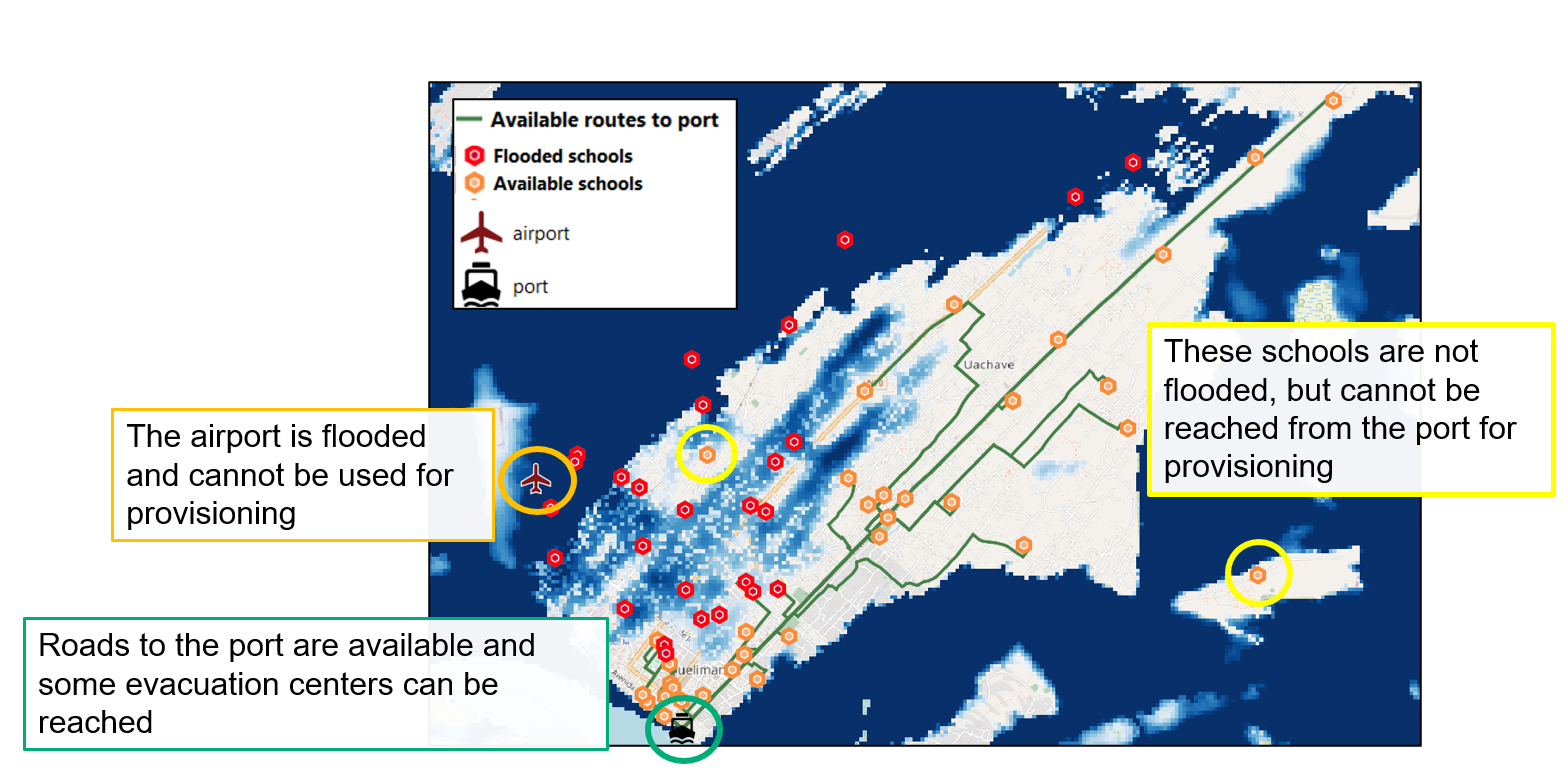